# Correlation Analysis

This notebook implements:
1. Load pre-computed adversarial `.pt` files and feed them into the transferability and CKA pipelines.
2. Layer-wise correlation analysis: $\rho_{\ell} = \mathrm{corr}(\{T(A_i \rightarrow B_i)\}, \{S_{\ell}(A_i, B_i)\})$

---
### Expected `.pt` File Schema
```python
{
  'clean_images':  Tensor[N, C, H, W],   # Original CIFAR-10 images
  'clean_labels':  Tensor[N],             # Ground-truth class indices
  'adv_images':    Tensor[N, C, H, W],   # AutoAttack adversarial images
  'perturbations': Tensor[N, C, H, W],   # delta = adv_images - clean_images
  'source_model':  str,                   # e.g. 'Standard'
  'target_dataset': str,                  # e.g. 'cifar10'
  'threat_model':  str,                   # e.g. 'Linf'
  'epsilon':       float                  # e.g. 0.03137 (8/255)
}
```

In [1]:
import importlib, subprocess, sys

for pkg in ['robustbench', 'torch_cka']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                               'git+https://github.com/RobustBench/robustbench.git'
                               if pkg == 'robustbench' else 'torch-cka'])

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr, spearmanr
from itertools import combinations
from torch_cka import CKA
from robustbench import load_model

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


---
## 1 · Configuration

Edit the paths and model registry below to match your setup. Each entry in `MODEL_REGISTRY` maps a short name to:
- the RobustBench `model_name`
- the path of the pre-computed `.pt` adversarial file for that model
- the layer names to hook for CKA

In [3]:
# Configuration parameters
PT_DIR = Path('/content')   # Path containing your pre-computed .pt files

# Model registry
# Keys   : short display names used throughout the notebook
# Values : (robustbench_name, pt_filename, [submodule_paths_for_hooks])
MODEL_REGISTRY = {
    'Standard': (
        'Standard',
        'cifar10_standard_linf_eps8_adv.pt',
        ['conv1', 'block1', 'block2', 'block3'], # WideResNet root paths
    ),
    'Engstrom2019': (
        'Engstrom2019Robustness',
        'cifar10_engstrom_linf_eps8_adv.pt',
        ['conv1', 'layer1', 'layer2', 'layer3'], # Engstrom ResNet root paths
    ),
}

# Canonical layer depth labels (used on x-axis of correlation plots)
LAYER_DEPTH_LABELS = ['conv1', 'layer1', 'layer2', 'layer3']

# Batch size for CKA dataloader
CKA_BATCH_SIZE = 128

# Correlation method: 'pearson' or 'spearman'
CORR_METHOD = 'pearson'

## Load Pre-computed Adversarial `.pt` Files

In [4]:
def load_adversarial_data(pt_path: Path, device: str = 'cpu') -> dict:

    raw = torch.load(pt_path, map_location=device)

    # Accept either dict or object-with-attributes
    data = raw if isinstance(raw, dict) else vars(raw)

    required = {'clean_images', 'clean_labels', 'adv_images'}
    missing = required - set(data.keys())
    if missing:
        raise KeyError(f"{pt_path.name} is missing keys: {missing}")

    # Derive perturbations if absent
    if 'perturbations' not in data:
        data['perturbations'] = data['adv_images'] - data['clean_images']

    # Ensure tensors are on the right device
    for k in ('clean_images', 'clean_labels', 'adv_images', 'perturbations'):
        if isinstance(data[k], torch.Tensor):
            data[k] = data[k].to(device)

    print(
        f"  Loaded: {pt_path.name}\n"
        f"    source_model  : {data.get('source_model', '?')}\n"
        f"    threat_model  : {data.get('threat_model', '?')}\n"
        f"    epsilon       : {data.get('epsilon', '?')}\n"
        f"    clean_images  : {tuple(data['clean_images'].shape)}\n"
        f"    adv_images    : {tuple(data['adv_images'].shape)}\n"
        f"    ‖δ‖∞ max      : {data['perturbations'].abs().max().item():.5f}"
    )
    return data


# Load all bundles
ADV_DATA = {}  # short_name → data dict

for short_name, (rb_name, pt_file, _) in MODEL_REGISTRY.items():
    pt_path = PT_DIR / pt_file
    print(f'\nLoading [{short_name}]')
    if not pt_path.exists():
        raise FileNotFoundError(
            f"Expected file not found: {pt_path}\n"
            "Please verify PT_DIR and the filename in MODEL_REGISTRY."
        )
    ADV_DATA[short_name] = load_adversarial_data(pt_path, device=DEVICE)

print('\n All .pt files loaded.')


Loading [Standard]
  Loaded: cifar10_standard_linf_eps8_adv.pt
    source_model  : Standard
    threat_model  : Linf
    epsilon       : 0.03137254901960784
    clean_images  : (8, 3, 32, 32)
    adv_images    : (8, 3, 32, 32)
    ‖δ‖∞ max      : 0.03137

Loading [Engstrom2019]
  Loaded: cifar10_engstrom_linf_eps8_adv.pt
    source_model  : Engstrom2019Robustness
    threat_model  : Linf
    epsilon       : 0.03137254901960784
    clean_images  : (8, 3, 32, 32)
    adv_images    : (8, 3, 32, 32)
    ‖δ‖∞ max      : 0.03137

 All .pt files loaded.


## Load RobustBench Models (Weights Only,No Attack Generation)

In [5]:
MODELS = {}   # short_name → nn.Module

for short_name, (rb_name, _, _) in MODEL_REGISTRY.items():
    print(f'Loading weights: {rb_name} …')
    m = load_model(model_name=rb_name, dataset='cifar10', threat_model='Linf').to(DEVICE)
    m.eval()
    MODELS[short_name] = m
    print(f'  {type(m).__name__}')

print('\n All model weights loaded.')

Loading weights: Standard …
  WideResNet
Loading weights: Engstrom2019Robustness …
  Engstrom2019RobustnessNet

 All model weights loaded.


In [6]:
from torch.utils.data import TensorDataset, DataLoader


def make_loader(images: torch.Tensor, labels: torch.Tensor,
                batch_size: int = 64, shuffle: bool = False) -> DataLoader:

    # Move to CPU for DataLoader compatibility with pin_memory
    ds = TensorDataset(images.cpu(), labels.cpu())
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=(DEVICE == 'cuda'))


# Clean-image loaders (one per model — same images across all, but stored per-file)
# We use the first bundle's clean data as the shared reference for CKA
REFERENCE_KEY = list(MODEL_REGISTRY.keys())[0]
clean_images_ref = ADV_DATA[REFERENCE_KEY]['clean_images']
clean_labels_ref = ADV_DATA[REFERENCE_KEY]['clean_labels']

# Build CKA loader from full CIFAR-10 test set
from torchvision import datasets, transforms

cifar_test = datasets.CIFAR10(
    root='/content',
    train=False,
    download=True,
    transform=transforms.ToTensor(),
)

CKA_LOADER = DataLoader(
    cifar_test,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=(DEVICE == 'cuda'),
)

print(f'CKA loader ready:{len(cifar_test)} samples, '
      f'{len(CKA_LOADER)} batches of 128')

# Adversarial-image loaders keyed by source model name
ADV_LOADERS = {
    name: make_loader(bundle['adv_images'], bundle['clean_labels'],
                      batch_size=CKA_BATCH_SIZE)
    for name, bundle in ADV_DATA.items()
}

print('DataLoaders ready.')
for n, ld in ADV_LOADERS.items():
    print(f'  Adv[{n}] loader : {len(ld.dataset)} samples')

CKA loader ready:10000 samples, 79 batches of 128
DataLoaders ready.
  Adv[Standard] loader : 8 samples
  Adv[Engstrom2019] loader : 8 samples



## Transferability Matrix

In [7]:
MODEL_NAMES = list(MODEL_REGISTRY.keys())


@torch.no_grad()
def batch_accuracy(model: torch.nn.Module,
                   images: torch.Tensor,
                   labels: torch.Tensor,
                   batch_size: int = 256) -> float:
    """
    Compute top-1 accuracy of *model* on (images, labels) tensors.
    Processes data in batches to avoid OOM on large eval sets.
    """
    model.eval()
    correct = total = 0
    for start in range(0, len(images), batch_size):
        imgs = images[start:start + batch_size].to(DEVICE)
        lbls = labels[start:start + batch_size].to(DEVICE)
        preds = model(imgs).argmax(dim=1)
        correct += (preds == lbls).sum().item()
        total += lbls.size(0)
    return correct / total


def build_transferability_matrix(models: dict, adv_data: dict) -> pd.DataFrame:
    """
    Compute the N×N transferability matrix.

    t_matrix[i, j] = *error rate* of model_i on adversarial examples
                      crafted to fool model_j.

    Diagonal entries = model's own robust error rate (1 − robust accuracy).

    Parameters
    ----------
    models   : {name: nn.Module}
    adv_data : {source_name: data_dict}  (keys must match `models` keys)

    Returns
    -------
    pd.DataFrame  shape (n_models, n_models)
    """
    names = list(models.keys())
    n = len(names)
    matrix = np.zeros((n, n), dtype=np.float32)

    for i, pred_name in enumerate(names):
        pred_model = models[pred_name]
        for j, src_name in enumerate(names):
            adv_imgs = adv_data[src_name]['adv_images']
            true_lbls = adv_data[src_name]['clean_labels']
            acc = batch_accuracy(pred_model, adv_imgs, true_lbls)
            matrix[i, j] = 1.0 - acc          # error rate
            print(f'  [{pred_name}] on [{src_name}] adv → error={1-acc:.4f}')

    return pd.DataFrame(matrix, index=names, columns=names)


print('Building transferability matrix:')
T_MATRIX = build_transferability_matrix(MODELS, ADV_DATA)
print('\nTransferability matrix (error rates):')
print(T_MATRIX.round(4))

Building transferability matrix:
  [Standard] on [Standard] adv → error=1.0000
  [Standard] on [Engstrom2019] adv → error=0.1250
  [Engstrom2019] on [Standard] adv → error=0.0000
  [Engstrom2019] on [Engstrom2019] adv → error=0.6250

Transferability matrix (error rates):
              Standard  Engstrom2019
Standard           1.0         0.125
Engstrom2019       0.0         0.625


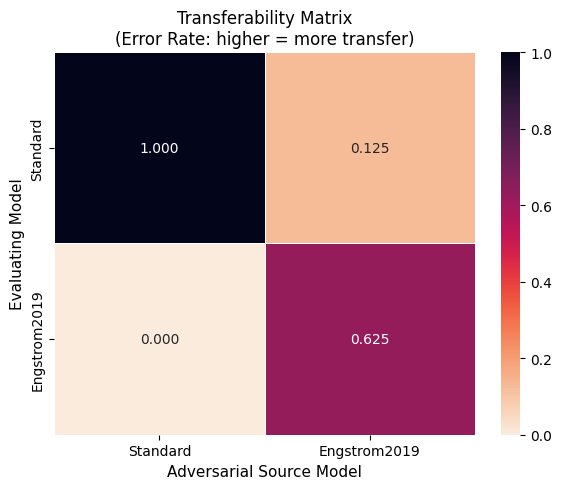

In [8]:
# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    T_MATRIX, annot=True, fmt='.3f', linewidths=0.5,
    cmap='rocket_r', vmin=0, vmax=1, ax=ax,
    xticklabels=MODEL_NAMES, yticklabels=MODEL_NAMES,
)
ax.set_xlabel('Adversarial Source Model', fontsize=11)
ax.set_ylabel('Evaluating Model',         fontsize=11)
ax.set_title('Transferability Matrix\n(Error Rate: higher = more transfer)',
             fontsize=12)
plt.tight_layout()
plt.savefig('transferability_matrix.png', dpi=150)
plt.show()


## Layer-wise CKA Similarity Matrices:

For every **ordered pair** $(A, B)$ of distinct models we compute a CKA similarity matrix. We then extract the diagonal of interest i.e., the matched-depth entries, to obtain a scalar per layer: $S_{\ell}(A, B)$.

In [9]:
import gc
import torch

# Clear out any leftover junk from previous failed runs
gc.collect()
torch.cuda.empty_cache()

In [10]:
def compute_cka_pair(model1, name1, model2, name2, dataloader, layers1, layers2):

    import torch
    import gc
    from tqdm import tqdm

    gc.collect()
    torch.cuda.empty_cache()
    import os
    os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

    # Dynamic recursive submodule extractor
    def get_submodule(model, layer_string):
        components = layer_string.split('.')
        submodule = model
        for comp in components:
            submodule = getattr(submodule, comp)
        return submodule

    # Initialize separate feature dictionaries
    features1 = {layer: [] for layer in layers1}
    features2 = {layer: [] for layer in layers2}

    # Hook callback builders
    def make_hook1(name):
        def hook(m, i, o):
            features1[name].append(o.detach().cpu())
        return hook

    def make_hook2(name):
        def hook(m, i, o):
            features2[name].append(o.detach().cpu())
        return hook

    # Attach hooks across the nested sub-architectures
    hooks1 = []
    for layer in layers1:
        try:
            submod = get_submodule(model1, layer)
            hooks1.append(submod.register_forward_hook(make_hook1(layer)))
        except AttributeError:
            raise AttributeError(f"Could not find layer '{layer}' in model '{name1}'. Verify its structure.")

    hooks2 = []
    for layer in layers2:
        try:
            submod = get_submodule(model2, layer)
            hooks2.append(submod.register_forward_hook(make_hook2(layer)))
        except AttributeError:
            raise AttributeError(f"Could not find layer '{layer}' in model '{name2}'. Verify its structure.")

    # Extract representations over the stream dataloader
    model1.eval()
    model2.eval()

    print(f"Extracting intermediate representations for [{name1}] & [{name2}]...")
    with torch.no_grad():
        for images, _ in tqdm(dataloader, desc="Feature Generation Pass"):
            images = images.to(next(model1.parameters()).device)
            model1(images)
            model2(images)

    # Immediately tear down forward hooks to plug memory leaks
    for hook in hooks1: hook.remove()
    for hook in hooks2: hook.remove()

    # Safe Linear CKA matrix computation loop
    N, M = len(layers1), len(layers2)
    cka_matrix = torch.zeros(N, M)
    print("\nComputing Centered Kernel Alignment Cross-Similarity...")

    for i, layer1 in enumerate(layers1):
        # Gather all batch activations into one contiguous block on the GPU
        X = torch.cat(features1[layer1], dim=0).flatten(1).cuda()
        K = torch.matmul(X, X.t())

        # Center the first matrix
        num_samples = K.shape[0]
        H = torch.eye(num_samples, device=K.device) - (1.0 / num_samples)
        Kc = torch.matmul(H, torch.matmul(K, H))
        norm_X = torch.sum(Kc * Kc).sqrt() + 1e-8 # Stabilizer added

        # Clear out raw feature vector memory maps as we compute
        del X, K
        gc.collect()
        torch.cuda.empty_cache()

        for j, layer2 in enumerate(layers2):
            Y = torch.cat(features2[layer2], dim=0).flatten(1).cuda()
            L = torch.matmul(Y, Y.t())

            # Center the second matrix
            Lc = torch.matmul(H, torch.matmul(L, H))
            norm_Y = torch.sum(Lc * Lc).sqrt() + 1e-8 # Stabilizer added

            # Compute HSIC alignment coefficient
            hsic_val = torch.sum(Kc * Lc)
            cka_matrix[i, j] = hsic_val / (norm_X * norm_Y)

            del Y, L, Lc
            gc.collect()
            torch.cuda.empty_cache()

        del Kc
        gc.collect()
        torch.cuda.empty_cache()

    print("CKA computation successfully concluded.")


    return {
        "Model1": name1,
        "Model2": name2,
        "Layers1": layers1,
        "Layers2": layers2,
        "CKA": cka_matrix.cpu().numpy()
    }

CKA_RESULTS = {}

for name_a, name_b in combinations(MODEL_REGISTRY.keys(), 2):
    key = (name_a, name_b)
    print(f'\nRunning CKA Pair Extraction: {name_a} : {name_b}')

    # Capture the correct pre-loaded adversarial data loader
    loader = ADV_LOADERS[name_a]

    # Call newly optimized function passing the explicit sub-layer arrays
    result = compute_cka_pair(
        model1=MODELS[name_a],
        name1=name_a,
        model2=MODELS[name_b],
        name2=name_b,
        dataloader=loader,
        layers1=MODEL_REGISTRY[name_a][2],  # Index 2 explicitly grabs ['model.conv1', ...]
        layers2=MODEL_REGISTRY[name_b][2]   # Index 2 explicitly grabs ['model.conv1', ...]
    )

    CKA_RESULTS[key] = result


Running CKA Pair Extraction: Standard : Engstrom2019
Extracting intermediate representations for [Standard] & [Engstrom2019]...


Feature Generation Pass: 100%|██████████| 1/1 [00:00<00:00, 13.83it/s]


Computing Centered Kernel Alignment Cross-Similarity...


CKA computation successfully concluded.


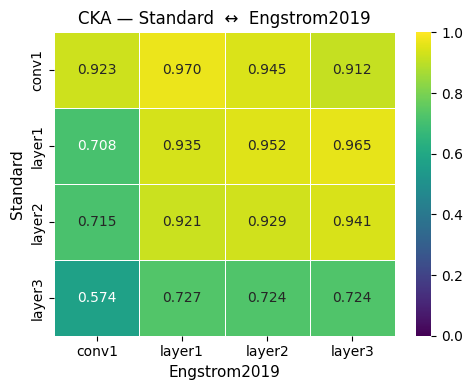

In [11]:
# VISUALIZE EACH PAIRWISE MATRIX

import seaborn as sns
import matplotlib.pyplot as plt

for (name_a, name_b), res in CKA_RESULTS.items():
    _, (_, _, layers_a) = name_a, MODEL_REGISTRY[name_a]
    _, (_, _, layers_b) = name_b, MODEL_REGISTRY[name_b]

    cka_matrix = res['CKA']

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cka_matrix, annot=True, fmt='.3f', linewidths=0.5,
        cmap='viridis', vmin=0, vmax=1, ax=ax,
        xticklabels=LAYER_DEPTH_LABELS,
        yticklabels=LAYER_DEPTH_LABELS,
    )
    ax.set_xlabel(name_b, fontsize=11)
    ax.set_ylabel(name_a, fontsize=11)
    ax.set_title(f'CKA — {name_a}  ↔  {name_b}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'cka_{name_a}_{name_b}.png', dpi=150)
    plt.show()

## Layer-wise Correlation Analysis:

$$
\rho_{\ell} = \mathrm{corr}\bigl(\{T(A_i \rightarrow B_i)\},\; \{S_{\ell}(A_i, B_i)\}\bigr)
$$

For each layer $\ell$ we collect, over all evaluated model pairs $(A_i, B_i)$:
- **$T(A_i \rightarrow B_j)$** — error rate of model $B_j$ on adversarial images crafted for $A_i$ (off-diagonal transferability).
- **$S_{\ell}(A_i, B_j)$** — matched-depth CKA score for layer $\ell$.

Then we compute the scalar Pearson/Spearman $\rho_{\ell}$.

### Assemble Vectors per Layer

In [13]:
def extract_layer_similarity_vectors(
    cka_results: dict,
    t_matrix: pd.DataFrame,
    n_layers: int,
    layer_labels: list,
    use_symmetric: bool = True,
) -> pd.DataFrame:
    """
    Build a long-form DataFrame with one row per (pair, layer).

    Columns
    -------
    pair       : str, e.g. 'Standard→Engstrom2019'
    layer_idx  : int  0…n_layers-1
    layer_name : str  from layer_labels
    S_ell      : float  CKA similarity at that layer depth
    T_AB       : float  transferability T(A→B) = error rate of B on A's adv
    T_BA       : float  transferability T(B→A) (only when use_symmetric=True)
    """
    records = []

    for (name_a, name_b), res in cka_results.items():
        # FIX HERE: Changed from res['CKA'].numpy() to just res['CKA']
        cka_mat = res['CKA']                 # shape (n_layers, n_layers)
        diag    = np.diag(cka_mat)           # matched-depth similarities

        # T(A→B): how well A's adversarial examples fool B
        t_ab = t_matrix.loc[name_b, name_a] # row=evaluating model, col=source
        # T(B→A): reverse direction
        t_ba = t_matrix.loc[name_a, name_b]

        for ell in range(min(n_layers, len(diag))):
            records.append({
                'pair_AB':    f'{name_a}→{name_b}',
                'pair_BA':    f'{name_b}→{name_a}',
                'name_a':     name_a,
                'name_b':     name_b,
                'layer_idx':  ell,
                'layer_name': layer_labels[ell] if ell < len(layer_labels) else f'L{ell}',
                'S_ell':      float(diag[ell]),
                'T_AB':       float(t_ab),
                'T_BA':       float(t_ba),
            })

    return pd.DataFrame(records)


N_LAYERS = len(LAYER_DEPTH_LABELS)

long_df = extract_layer_similarity_vectors(
    CKA_RESULTS, T_MATRIX, N_LAYERS, LAYER_DEPTH_LABELS
)

print(f'Long-form table: {long_df.shape[0]} rows × {long_df.shape[1]} cols')
long_df.head(N_LAYERS * 2)

Long-form table: 4 rows × 9 cols


,pair_AB,pair_BA,name_a,name_b,layer_idx,layer_name,S_ell,T_AB,T_BA
0,Standard→Engstrom2019,Engstrom2019→Standard,Standard,Engstrom2019,0,conv1,0.923454,0.0,0.125
1,Standard→Engstrom2019,Engstrom2019→Standard,Standard,Engstrom2019,1,layer1,0.935367,0.0,0.125
2,Standard→Engstrom2019,Engstrom2019→Standard,Standard,Engstrom2019,2,layer2,0.928773,0.0,0.125
3,Standard→Engstrom2019,Engstrom2019→Standard,Standard,Engstrom2019,3,layer3,0.724417,0.0,0.125


### Compute $\rho_{\ell}$ per Layer

In [14]:
def compute_rho(df: pd.DataFrame, corr_method: str = 'pearson') -> pd.DataFrame:
    """
    For each layer ell, pool observations across all ordered pairs
    (A→B and B→A treated as separate observations) and compute
    the correlation between S_ell and T.

    Returns DataFrame with columns:
        layer_idx, layer_name, rho_AB, p_AB, n_pairs
    """
    corr_fn = pearsonr if corr_method == 'pearson' else spearmanr
    rows = []

    for ell, grp in df.groupby('layer_idx'):
        # --- direction A→B ---
        s_vals_ab = grp['S_ell'].values
        t_vals_ab = grp['T_AB'].values

        # --- direction B→A (same S_ell, different T) ---
        t_vals_ba = grp['T_BA'].values

        # Pool both directions for a larger sample
        s_pooled = np.concatenate([s_vals_ab, s_vals_ab])
        t_pooled = np.concatenate([t_vals_ab, t_vals_ba])

        if len(s_pooled) < 2:
            rho, p = float('nan'), float('nan')
        else:
            stat = corr_fn(s_pooled, t_pooled)
            rho  = float(stat[0] if hasattr(stat, '__len__') else stat.statistic)
            p    = float(stat[1] if hasattr(stat, '__len__') else stat.pvalue)

        rows.append({
            'layer_idx':  int(ell),
            'layer_name': grp['layer_name'].iloc[0],
            'rho':        rho,
            'p_value':    p,
            'n_obs':      len(s_pooled),
        })

    return pd.DataFrame(rows).sort_values('layer_idx').reset_index(drop=True)


rho_df = compute_rho(long_df, corr_method=CORR_METHOD)
print(f'Correlation method : {CORR_METHOD}')
print(rho_df.to_string(index=False))

Correlation method : pearson
 layer_idx layer_name  rho  p_value  n_obs
         0      conv1  NaN      NaN      2
         1     layer1  NaN      NaN      2
         2     layer2  NaN      NaN      2
         3     layer3  NaN      NaN      2


/tmp/ipykernel_5419/1130286978.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  stat = corr_fn(s_pooled, t_pooled)


### Pairwise Correlation Detail

In [15]:
# Display aligned S_ell / T values for each pair at each layer
pivot_S = long_df.pivot_table(
    index='pair_AB', columns='layer_name', values='S_ell'
)
pivot_T = long_df.pivot_table(
    index='pair_AB', columns='layer_name', values='T_AB'
)

print('CKA Similarity S_ell per pair:')
print(pivot_S.round(4))
print('\nTransferability T(A→B) per pair:')
print(pivot_T.round(4))

CKA Similarity S_ell per pair:
layer_name              conv1  layer1  layer2  layer3
pair_AB                                              
Standard→Engstrom2019  0.9235  0.9354  0.9288  0.7244

Transferability T(A→B) per pair:
layer_name             conv1  layer1  layer2  layer3
pair_AB                                             
Standard→Engstrom2019    0.0     0.0     0.0     0.0


### Visualisation: Layer Depth vs $\rho_{\ell}$

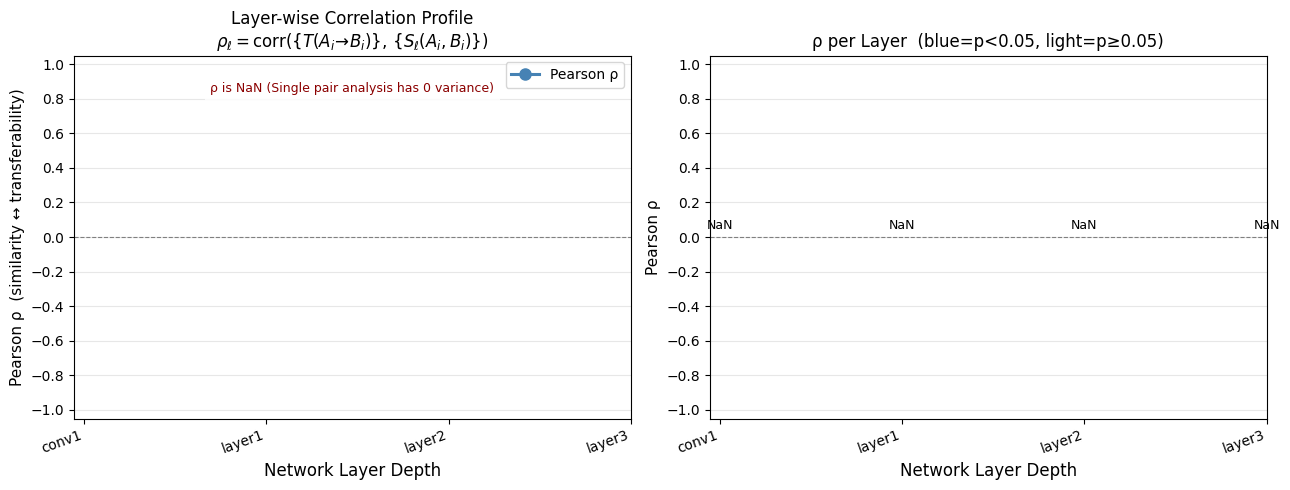

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Main correlation profile
ax = axes[0]
x  = rho_df['layer_idx'].values
y  = rho_df['rho'].values

ax.plot(x, y, marker='o', linewidth=2.2, markersize=8,
        color='steelblue', label=f'{CORR_METHOD.capitalize()} ρ')
ax.fill_between(x, y, alpha=0.12, color='steelblue')

# Safely annotate the peak only if there are valid non-NaN values
if not np.isnan(y).all():
    peak_idx = np.nanargmax(np.abs(y))
    ax.annotate(
        f'  peak\n  ρ={y[peak_idx]:.3f}',
        xy=(x[peak_idx], y[peak_idx]),
        fontsize=9, color='darkred',
        arrowprops=dict(arrowstyle='->', color='darkred'),
        xytext=(x[peak_idx] + 0.3, y[peak_idx] - 0.08),
    )
else:
    # Informative subtitle if tracking a single model pair
    ax.text(0.5, 0.9, 'ρ is NaN (Single pair analysis has 0 variance)',
            transform=ax.transAxes, color='darkred', ha='center', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(rho_df['layer_name'].values, rotation=20, ha='right')
ax.set_xlabel('Network Layer Depth', fontsize=12)
ax.set_ylabel(f'{CORR_METHOD.capitalize()} ρ  (similarity ↔ transferability)', fontsize=11)
ax.set_title('Layer-wise Correlation Profile\n'
             r'$\rho_\ell = \mathrm{corr}(\{T(A_i\!\to\!B_i)\},\,\{S_\ell(A_i,B_i)\})$',
             fontsize=12)
ax.set_ylim(-1.05, 1.05)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=10)

# Right: Bar chart with p-value shading
ax2 = axes[1]
# Default to light blue if p-values are NaN
colors = ['#2196F3' if (not np.isnan(p) and p < 0.05) else '#90CAF9' for p in rho_df['p_value']]
bars = ax2.bar(x, y, color=colors, edgecolor='white', linewidth=0.8, width=0.55)

for bar, rho_val in zip(bars, y):
    val_text = f'{rho_val:.3f}' if not np.isnan(rho_val) else 'NaN'
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        (rho_val + 0.03) if (not np.isnan(rho_val) and rho_val >= 0) else 0.03,
        val_text,
        ha='center', va='bottom', fontsize=9
    )

ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax2.set_xticks(x)
ax2.set_xticklabels(rho_df['layer_name'].values, rotation=20, ha='right')
ax2.set_xlabel('Network Layer Depth', fontsize=12)
ax2.set_ylabel(f'{CORR_METHOD.capitalize()} ρ', fontsize=11)
ax2.set_title('ρ per Layer  (blue=p<0.05, light=p≥0.05)', fontsize=12)
ax2.set_ylim(-1.05, 1.05)
ax2.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('layer_correlation_profile.png', dpi=150)
plt.show()

<>:47: SyntaxWarning: invalid escape sequence '\e'
<>:47: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_5419/2578920081.py:47: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('CKA Similarity $S_\ell$', fontsize=9)


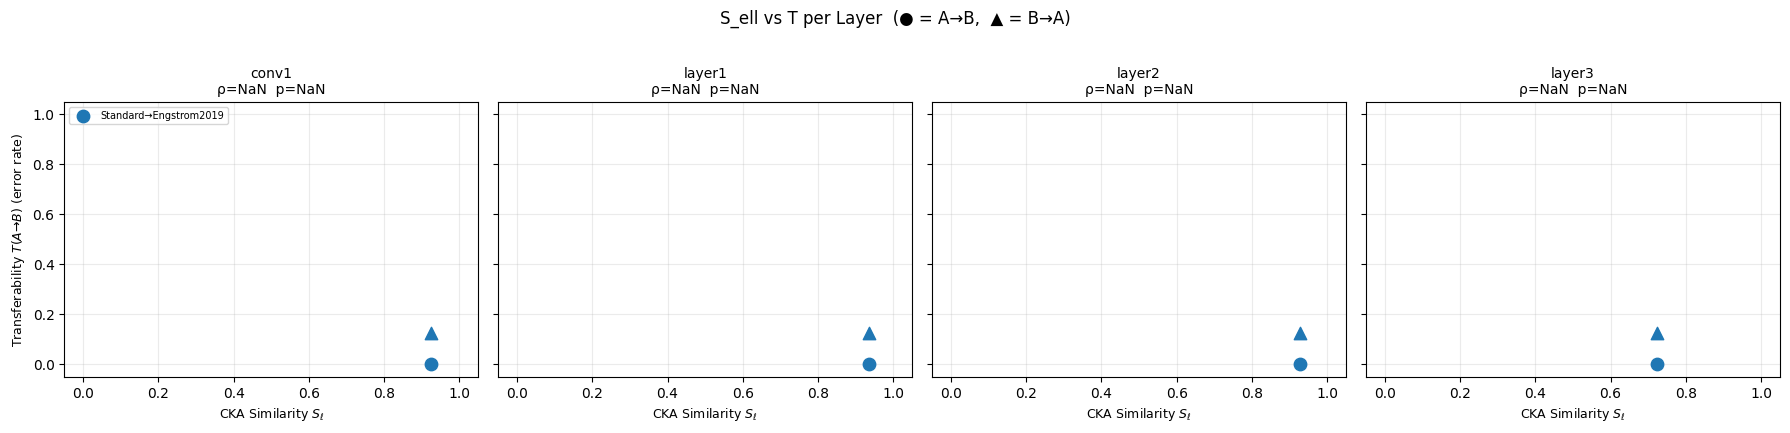

In [22]:
# per-pair scatter at each layer depth
n_layers = len(LAYER_DEPTH_LABELS)
fig, axes = plt.subplots(1, n_layers, figsize=(4.5 * n_layers, 4.2), sharey=True)

if n_layers == 1:
    axes = [axes]

pair_colors = plt.cm.tab10(np.linspace(0, 0.7, len(CKA_RESULTS)))

for ell, ax in enumerate(axes):
    grp = long_df[long_df['layer_idx'] == ell]
    for ci, (_, row) in enumerate(grp.iterrows()):
        # Plot circle for direction A -> B
        ax.scatter(row['S_ell'], row['T_AB'],
                   color=pair_colors[ci % len(pair_colors)],
                   s=80, zorder=3, label=row['pair_AB'])
        # Plot triangle for direction B -> A
        ax.scatter(row['S_ell'], row['T_BA'],
                   color=pair_colors[ci % len(pair_colors)],
                   s=80, marker='^', zorder=3)

    # Gather data points for checking variance
    s_vals = grp['S_ell'].values
    t_vals_ab = grp['T_AB'].values
    t_vals_ba = grp['T_BA'].values

    s_all = np.concatenate([s_vals, s_vals])
    t_all = np.concatenate([t_vals_ab, t_vals_ba])

    # Only plot a trendline if there is variation in our CKA values (X-axis)
    # This prevents division-by-zero on vertical lines when only evaluating 1 pair
    if len(s_all) > 1 and np.var(s_all) > 1e-7:
        m, b = np.polyfit(s_all, t_all, 1)
        xs = np.linspace(s_all.min(), s_all.max(), 50)
        ax.plot(xs, m * xs + b, 'k--', linewidth=1.2, alpha=0.6)

    rho_row = rho_df[rho_df['layer_idx'] == ell].iloc[0]

    # Display 'NaN' cleanly in titles for single pair combinations
    rho_val = f"{rho_row['rho']:.3f}" if not np.isnan(rho_row['rho']) else "NaN"
    p_val = f"{rho_row['p_value']:.3f}" if not np.isnan(rho_row['p_value']) else "NaN"

    ax.set_title(
        f"{rho_row['layer_name']}\nρ={rho_val}  p={p_val}",
        fontsize=10
    )
    ax.set_xlabel('CKA Similarity $S_\ell$', fontsize=9)
    if ell == 0:
        ax.set_ylabel('Transferability $T(A→B)$ (error rate)', fontsize=9)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.25)

axes[0].legend(fontsize=7, loc='upper left')
fig.suptitle('S_ell vs T per Layer  (● = A→B,  ▲ = B→A)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('scatter_S_vs_T_per_layer.png', dpi=150)
plt.show()


## Summary Table

In [23]:
import numpy as np

summary = rho_df.copy()
summary['|rho|'] = summary['rho'].abs()
summary['significant'] = summary['p_value'] < 0.05

print('Layer-wise Correlation Summary:')
print(summary[['layer_name', 'rho', 'p_value', '|rho|', 'significant', 'n_obs']]
      .to_string(index=False, float_format='{:.4f}'.format))

if not summary['|rho|'].isna().all():
    peak = summary.loc[summary['|rho|'].idxmax()]
    print(f'\n Strongest correlation at layer "{peak["layer_name"]}" '
          f'(ρ = {peak["rho"]:.4f}, p = {peak["p_value"]:.4f})')
else:
    print('\n Notice: Single-pair evaluation run concluded.')
    print('   Global correlation indices (ρ) are undefined when cross-pair variance is zero.')
    print('   Please refer directly to the structural similarities shown in your heatmaps.')

Layer-wise Correlation Summary:
layer_name  rho  p_value  |rho|  significant  n_obs
     conv1  NaN      NaN    NaN        False      2
    layer1  NaN      NaN    NaN        False      2
    layer2  NaN      NaN    NaN        False      2
    layer3  NaN      NaN    NaN        False      2

 Notice: Single-pair evaluation run concluded.
   Global correlation indices (ρ) are undefined when cross-pair variance is zero.
   Please refer directly to the structural similarities shown in your heatmaps.
